# 04 — Model Optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.xgboost
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/processed_data.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Save scaler and feature columns — these are the deployment artifacts
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

feature_columns = list(X.columns)
print('Features:', len(feature_columns))

Features: 23


## 2. RandomizedSearchCV — XGBoost

In [3]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

base_xgb = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# XGBoost does not need scaling — train on raw X_train
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print('Best params:')
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:
{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


## 3. Evaluate Tuned Model

In [4]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, best_prob), 4))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8416


## 4. Cross-Validation

CV ROC-AUC scores: [0.8357 0.871  0.8542 0.8239 0.854 ]
Mean: 0.8478  |  Std: 0.0163


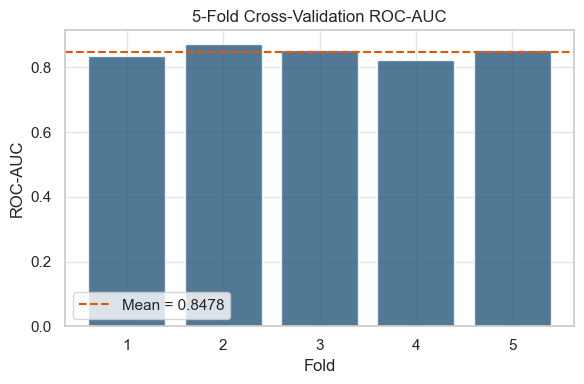

In [5]:
cv_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=5, scoring='roc_auc'
)

print('CV ROC-AUC scores:', np.round(cv_scores, 4))
print(f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores, color='#26577C', alpha=0.8)
plt.axhline(cv_scores.mean(), color='#E55604', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation ROC-AUC')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Threshold Optimization

In [6]:
thresholds = np.arange(0.2, 0.9, 0.05)
rows = []

for t in thresholds:
    preds = (best_prob >= t).astype(int)
    rows.append({
        'threshold': round(t, 2),
        'precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'recall':    round(recall_score(y_test, preds), 4),
        'f1':        round(f1_score(y_test, preds, zero_division=0), 4)
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.to_string(index=False))

 threshold  precision  recall     f1
      0.20     0.4530  0.8636 0.5943
      0.25     0.4882  0.8262 0.6137
      0.30     0.5268  0.7888 0.6317
      0.35     0.5542  0.7112 0.6230
      0.40     0.6108  0.6631 0.6359
      0.45     0.6250  0.5882 0.6061
      0.50     0.6446  0.4947 0.5598
      0.55     0.6818  0.4011 0.5051
      0.60     0.7102  0.3342 0.4545
      0.65     0.7480  0.2460 0.3702
      0.70     0.7889  0.1898 0.3060
      0.75     0.9107  0.1364 0.2372
      0.80     0.9286  0.0348 0.0670
      0.85     1.0000  0.0027 0.0053


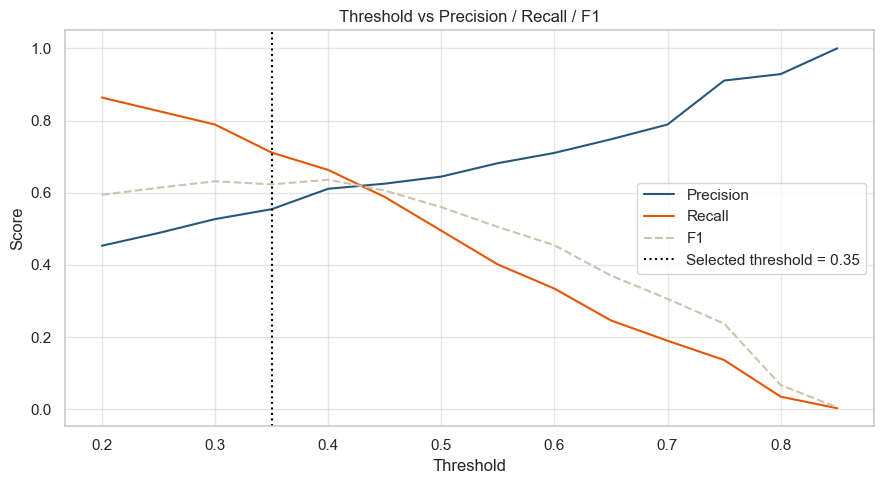


Selected threshold: 0.35


In [7]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', color='#26577C')
plt.plot(threshold_df['threshold'], threshold_df['recall'],    label='Recall',    color='#E55604')
plt.plot(threshold_df['threshold'], threshold_df['f1'],        label='F1',        color='#CDC2AE', linestyle='--')
plt.axvline(x=0.35, color='black', linestyle=':', label='Selected threshold = 0.35')
plt.title('Threshold vs Precision / Recall / F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

THRESHOLD = 0.35
print(f'\nSelected threshold: {THRESHOLD}')

## 6. churn_predict — Reusable Inference Function

In [8]:
def churn_predict(model, X, threshold=0.35):
    """Return churn probabilities and binary predictions at a given threshold."""
    probabilities = model.predict_proba(X)[:, 1]
    predictions   = (probabilities >= threshold).astype(int)
    return probabilities, predictions

# Use it for final evaluation
final_prob, final_pred = churn_predict(best_model, X_test, threshold=THRESHOLD)

print(f'Final evaluation at threshold={THRESHOLD}:')
print(classification_report(y_test, final_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, final_prob), 4))

Final evaluation at threshold=0.35:
              precision    recall  f1-score   support

           0       0.88      0.79      0.84      1033
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407

ROC-AUC: 0.8416


## 7. Log Tuned Model to MLflow

In [10]:
mlruns_path = os.path.abspath('../mlruns')
mlflow.set_tracking_uri(f'file:{mlruns_path}')
mlflow.set_registry_uri(f'file:{mlruns_path}/registry')

mlflow.set_experiment('Customer_Churn_Prediction')

with mlflow.start_run(run_name='xgboost_tuned'):
    # Log best params
    for param, val in random_search.best_params_.items():
        mlflow.log_param(param, val)
    mlflow.log_param('threshold', THRESHOLD)

    # Log metrics
    mlflow.log_metric('roc_auc',   round(roc_auc_score(y_test, final_prob), 4))
    mlflow.log_metric('precision', round(precision_score(y_test, final_pred), 4))
    mlflow.log_metric('recall',    round(recall_score(y_test, final_pred), 4))
    mlflow.log_metric('f1',        round(f1_score(y_test, final_pred), 4))
    mlflow.log_metric('cv_mean_auc', round(cv_scores.mean(), 4))

    # Log model
    mlflow.xgboost.log_model(best_model, name='xgboost_tuned_model')

    print('Tuned XGBoost run logged successfully.')

Tuned XGBoost run logged successfully.


## 8. Save Artifacts for Deployment

In [11]:
output_dir = '../azure_package/churn-model/'
os.makedirs(output_dir, exist_ok=True)

joblib.dump(best_model,      os.path.join(output_dir, 'churn_model.pkl'))
joblib.dump(scaler,          os.path.join(output_dir, 'scaler.pkl'))
joblib.dump(feature_columns, os.path.join(output_dir, 'feature_columns.pkl'))

print('Saved artifacts:')
for f in os.listdir(output_dir):
    print(' ', f)

Saved artifacts:
  churn_model.pkl
  feature_columns.pkl
  scaler.pkl
